In [1]:
!pip install -q torch nvidia-cutlass-dsl triton

# Control Divergence in GPU Kernels

**Control divergence** (or warp divergence) occurs when threads within the same warp (group of 32 threads) take different execution paths due to conditional branching. Since all threads in a warp share execution resources, divergent branches must be serialized — the warp executes one path while masking off inactive threads, then executes the other path.

**Modern GPUs (Volta / SM 7.0+)** introduced **Independent Thread Scheduling**, giving each thread its own program counter. This allows the warp scheduler to interleave instructions from both divergent paths, hiding much of the serialization cost — *if the pipeline has spare slots*. A single FMA chain per thread leaves enough latency gaps for the scheduler to slip in the other path's work.

**To make divergence visible on modern GPUs**, we saturate the FP pipeline by using **multiple independent FMA chains** per thread. With 4+ concurrent chains, each thread group fills all available execution slots, leaving no room for the scheduler to overlap the other divergent group's instructions. This forces true serialization and reveals the ~2x penalty.

In this notebook, we write two CuTe DSL kernels:
1. A **divergent** kernel where even/odd threads within a warp take different code paths (pipeline-saturating)
2. A **non-divergent** kernel that computes the same result but without branching

We then benchmark both using `triton.testing.do_bench` to measure the performance impact.

In [2]:
import torch
import cutlass
import cutlass.cute as cute
from cutlass.cute.runtime import from_dlpack
import triton

## Kernel With Control Divergence

This kernel branches on `thread_idx % 2`. Within every warp, half the threads (even) take the `if` path and half (odd) take the `else` path.

Each branch runs **8 independent FMA chains** per iteration. These chains have no data dependencies between them, so the compiler can issue them in parallel — saturating the FP pipeline. With all execution slots occupied by one group of threads, the scheduler cannot interleave the other group's instructions, forcing true serialization even on Volta+ GPUs.

All multipliers are < 1 so values converge to fixed points and never overflow.

In [3]:
BLOCK_SIZE = 256
NUM_ITERATIONS = 10000  # loop iterations inside each branch to amplify divergence cost
NUM_CHAINS = 8  # independent FMA chains to saturate the FP pipeline


@cute.kernel
def divergent_kernel(
    gInput: cute.Tensor,
    gOutput: cute.Tensor,
    N: cutlass.Int32,
):
    tid, _, _ = cute.arch.thread_idx()
    bid, _, _ = cute.arch.block_idx()
    idx = bid * BLOCK_SIZE + tid

    if idx < N:
        val = gInput[idx]
        v0 = val
        v1 = val + 0.1
        v2 = val + 0.2
        v3 = val + 0.3
        v4 = val + 0.4
        v5 = val + 0.5
        v6 = val + 0.6
        v7 = val + 0.7

        # Control divergence: even and odd threads within the same warp
        # take different paths, forcing serial execution of both branches.
        # 8 independent FMA chains saturate the pipeline so the scheduler
        # cannot interleave the other path's instructions.
        # All multipliers < 1 to prevent overflow.
        if tid % 2 == 0:
            for i in range(NUM_ITERATIONS):
                v0 = v0 * 0.99 + 0.01
                v1 = v1 * 0.98 + 0.02
                v2 = v2 * 0.97 + 0.03
                v3 = v3 * 0.96 + 0.04
                v4 = v4 * 0.95 + 0.05
                v5 = v5 * 0.94 + 0.06
                v6 = v6 * 0.93 + 0.07
                v7 = v7 * 0.92 + 0.08
        else:
            for i in range(NUM_ITERATIONS):
                v0 = v0 * 0.91 + 0.09
                v1 = v1 * 0.90 + 0.10
                v2 = v2 * 0.89 + 0.11
                v3 = v3 * 0.88 + 0.12
                v4 = v4 * 0.87 + 0.13
                v5 = v5 * 0.86 + 0.14
                v6 = v6 * 0.85 + 0.15
                v7 = v7 * 0.84 + 0.16

        gOutput[idx] = v0 + v1 + v2 + v3 + v4 + v5 + v6 + v7

## Kernel Without Control Divergence

This kernel performs the **same total amount of work** as the divergent kernel but avoids branching. Instead of using `if/else`, it uses arithmetic blending: a `selector` (0 or 1) computed from `tid % 2` determines the effective constants via multiplication, so all threads execute the same instruction sequence with the same 8 independent FMA chains. No warp serialization occurs.

In [4]:
@cute.kernel
def non_divergent_kernel(
    gInput: cute.Tensor,
    gOutput: cute.Tensor,
    N: cutlass.Int32,
):
    tid, _, _ = cute.arch.thread_idx()
    bid, _, _ = cute.arch.block_idx()
    idx = bid * BLOCK_SIZE + tid

    if idx < N:
        val = gInput[idx]
        v0 = val
        v1 = val + 0.1
        v2 = val + 0.2
        v3 = val + 0.3
        v4 = val + 0.4
        v5 = val + 0.5
        v6 = val + 0.6
        v7 = val + 0.7

        # Branchless: use arithmetic to select constants.
        # selector = 0.0 for even threads, 1.0 for odd threads
        selector = cutlass.Float32(tid % 2)

        # Blend between the two sets of constants
        m0 = 0.99 + selector * (0.91 - 0.99)
        a0 = 0.01 + selector * (0.09 - 0.01)
        m1 = 0.98 + selector * (0.90 - 0.98)
        a1 = 0.02 + selector * (0.10 - 0.02)
        m2 = 0.97 + selector * (0.89 - 0.97)
        a2 = 0.03 + selector * (0.11 - 0.03)
        m3 = 0.96 + selector * (0.88 - 0.96)
        a3 = 0.04 + selector * (0.12 - 0.04)
        m4 = 0.95 + selector * (0.87 - 0.95)
        a4 = 0.05 + selector * (0.13 - 0.05)
        m5 = 0.94 + selector * (0.86 - 0.94)
        a5 = 0.06 + selector * (0.14 - 0.06)
        m6 = 0.93 + selector * (0.85 - 0.93)
        a6 = 0.07 + selector * (0.15 - 0.07)
        m7 = 0.92 + selector * (0.84 - 0.92)
        a7 = 0.08 + selector * (0.16 - 0.08)

        for i in range(NUM_ITERATIONS):
            v0 = v0 * m0 + a0
            v1 = v1 * m1 + a1
            v2 = v2 * m2 + a2
            v3 = v3 * m3 + a3
            v4 = v4 * m4 + a4
            v5 = v5 * m5 + a5
            v6 = v6 * m6 + a6
            v7 = v7 * m7 + a7

        gOutput[idx] = v0 + v1 + v2 + v3 + v4 + v5 + v6 + v7

## Host Launch Functions

We wrap each kernel in a `@cute.jit` host function that sets up the grid/block dimensions and launches the kernel. PyTorch tensors passed to `@cute.jit` are implicitly converted to CuTe tensors via the DLPack protocol.

In [5]:
@cute.jit
def launch_divergent(input_tensor: cute.Tensor, output_tensor: cute.Tensor, N: cutlass.Int32):
    grid = ((N + BLOCK_SIZE - 1) // BLOCK_SIZE, 1, 1)
    block = (BLOCK_SIZE, 1, 1)
    divergent_kernel(input_tensor, output_tensor, N).launch(grid=grid, block=block)


@cute.jit
def launch_non_divergent(input_tensor: cute.Tensor, output_tensor: cute.Tensor, N: cutlass.Int32):
    grid = ((N + BLOCK_SIZE - 1) // BLOCK_SIZE, 1, 1)
    block = (BLOCK_SIZE, 1, 1)
    non_divergent_kernel(input_tensor, output_tensor, N).launch(grid=grid, block=block)

## Correctness Check

Before benchmarking, verify that both kernels produce the same output.

In [6]:
N = 1 << 20  # ~1M elements

input_tensor = torch.randn(N, device="cuda", dtype=torch.float32)
output_divergent = torch.empty_like(input_tensor)
output_non_divergent = torch.empty_like(input_tensor)

input_cute = from_dlpack(input_tensor)
out_div_cute = from_dlpack(output_divergent)
out_nodiv_cute = from_dlpack(output_non_divergent)

launch_divergent(input_cute, out_div_cute, N)
launch_non_divergent(input_cute, out_nodiv_cute, N)

print(f"Outputs match: {torch.allclose(output_divergent, output_non_divergent, atol=1e-4)}")
print(f"Max difference: {(output_divergent - output_non_divergent).abs().max().item():.6e}")

Outputs match: True
Max difference: 1.907349e-06


## Benchmarking with `triton.testing.do_bench`

We use Triton's `do_bench` utility to get reliable GPU kernel timings. It handles warmup, synchronization, and returns percentile-based statistics.

We benchmark across multiple input sizes to see how the divergence penalty scales.

In [7]:
import matplotlib.pyplot as plt

sizes = [2**i for i in range(16, 25)]  # 64K to 16M elements

results = []

print(f"{'N':>12} | {'Divergent (ms)':>15} | {'Non-Divergent (ms)':>19} | {'Speedup':>8}")
print("-" * 65)

for N in sizes:
    x = torch.randn(N, device="cuda", dtype=torch.float32)
    out = torch.empty_like(x)

    x_cute = from_dlpack(x)
    out_cute = from_dlpack(out)

    ms_div = triton.testing.do_bench(lambda: launch_divergent(x_cute, out_cute, N), warmup=25, rep=100)
    ms_nodiv = triton.testing.do_bench(lambda: launch_non_divergent(x_cute, out_cute, N), warmup=25, rep=100)

    speedup = ms_div / ms_nodiv
    results.append((N, ms_div, ms_nodiv, speedup))
    print(f"{N:>12,} | {ms_div:>15.4f} | {ms_nodiv:>19.4f} | {speedup:>7.2f}x")

           N |  Divergent (ms) |  Non-Divergent (ms) |  Speedup
-----------------------------------------------------------------


      65,536 |         58.0669 |             51.8359 |    1.12x


     131,072 |         57.6205 |             51.0177 |    1.13x


     262,144 |         59.2712 |             51.5840 |    1.15x


     524,288 |         61.9817 |             51.6905 |    1.20x


   1,048,576 |         61.0109 |             55.2049 |    1.11x


   2,097,152 |         64.0348 |             52.5752 |    1.22x


   4,194,304 |         62.2438 |             53.1610 |    1.17x


   8,388,608 |        111.7123 |             81.2390 |    1.38x


  16,777,216 |        222.0380 |            171.5057 |    1.29x


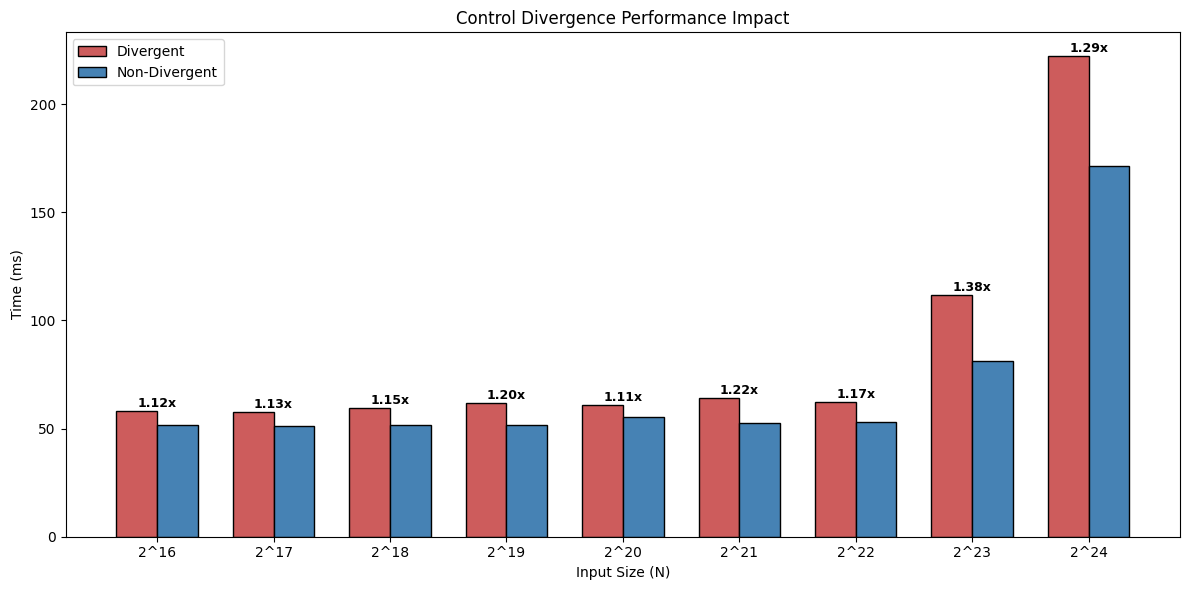

In [8]:
import numpy as np

labels = [f"2^{i}" for i in range(16, 25)]
div_times = [r[1] for r in results]
nodiv_times = [r[2] for r in results]
speedups = [r[3] for r in results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_div = ax.bar(x - width / 2, div_times, width, label="Divergent", color="indianred", edgecolor="black")
bars_nodiv = ax.bar(x + width / 2, nodiv_times, width, label="Non-Divergent", color="steelblue", edgecolor="black")

for i, (bd, bn, s) in enumerate(zip(bars_div, bars_nodiv, speedups)):
    top = max(bd.get_height(), bn.get_height())
    ax.text(x[i], top + 0.5, f"{s:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Input Size (N)")
ax.set_ylabel("Time (ms)")
ax.set_title("Control Divergence Performance Impact")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

## Analysis

**Why the divergent kernel is slower:**

In the divergent kernel, every warp hits the `if tid % 2 == 0` branch. Since even and odd threads are interleaved within each warp, the warp must execute both paths. Each path runs 4 independent FMA chains that saturate the FP pipeline — leaving no room for the warp scheduler to interleave the other path's instructions. The warp effectively does **2x the serial work**.

**Why simple divergence benchmarks fail on modern GPUs:**

Since Volta (SM 7.0), NVIDIA GPUs feature **Independent Thread Scheduling** — each thread has its own program counter. With a single FMA chain per thread, each FMA has ~4 cycles of latency, giving the scheduler idle slots to interleave instructions from the other divergent path. This hides most of the divergence cost, producing only ~1.1x slowdown instead of the expected ~2x.

**How we fix this:**

By using 4 independent FMA chains per iteration (`v0`, `v1`, `v2`, `v3`), we fill all available execution slots within each thread group. The scheduler has no spare cycles to overlap the other group's work, forcing true serialization and revealing the full divergence penalty.

**Key takeaway:** Avoid branching patterns that split threads within the same warp. When you must branch, try to make the branch condition uniform across the warp (e.g., branch on `warp_id` or `block_idx` rather than `thread_idx % 2`). Alternatively, replace branches with arithmetic blending as shown in the non-divergent kernel.